In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

from statsmodels.tsa.holtwinters import ExponentialSmoothing

In [2]:
# Load yearly demand — drop partial years (2002 starts May, 2026 is incomplete)
df = pd.read_csv('./data/Yearly_Market_Demand_2002-2026.csv')
df = df[(df['Year'] >= 2003) & (df['Year'] <= 2025)].copy()
df['Year'] = df['Year'].astype(int)
df['TWh'] = df['Total_Market_Demand'] / 1e6  # MWh → TWh

print(df[['Year', 'TWh']].to_string())


    Year         TWh
1   2003  157.982144
2   2004  162.925342
3   2005  167.153184
4   2006  162.442513
5   2007  164.491422
6   2008  170.876581
7   2009  154.300535
8   2010  157.360156
9   2011  154.319233
10  2012  155.905911
11  2013  158.542864
12  2014  158.273142
13  2015  159.031052
14  2016  158.174232
15  2017  150.578393
16  2018  155.631773
17  2019  154.455959
18  2020  152.173361
19  2021  150.607860
20  2022  154.593808
21  2023  152.796391
22  2024  158.303840
23  2025  165.511186


In [3]:
# Fit three models on historical data
years = df['Year'].values
twh   = df['TWh'].values
all_years = np.arange(2003, 2051)

X_hist = years.reshape(-1, 1)
X_all  = all_years.reshape(-1, 1)

# 1. Linear regression
lin = LinearRegression().fit(X_hist, twh)
lin_pred = lin.predict(X_all)

# 2. Polynomial degree-2 (captures the decline → recent uptick)
poly2 = make_pipeline(PolynomialFeatures(2), LinearRegression())
poly2.fit(X_hist, twh)
poly2_pred = poly2.predict(X_all)

# 3. Holt's exponential smoothing (damped additive trend)
holt = ExponentialSmoothing(twh, trend='add', damped_trend=True,
                            initialization_method='estimated').fit()
holt_hist = holt.fittedvalues
holt_fcast = holt.forecast(2050 - 2025)
holt_pred = np.concatenate([holt_hist, holt_fcast])

print(f"{'Model':<12} {'2030':>8} {'2040':>8} {'2050':>8}")
print("-" * 38)
for name, pred in [('Linear', lin_pred), ('Poly-2', poly2_pred), ('Holt', holt_pred)]:
    idx30 = np.where(all_years == 2030)[0][0]
    idx40 = np.where(all_years == 2040)[0][0]
    idx50 = len(pred) - 1
    print(f"{name:<12} {pred[idx30]:>7.1f}  {pred[idx40]:>7.1f}  {pred[idx50]:>7.1f}")


Model            2030     2040     2050
--------------------------------------
Linear         152.1    148.4    144.7
Poly-2         161.6    176.7    200.7
Holt           154.6    154.2    154.1


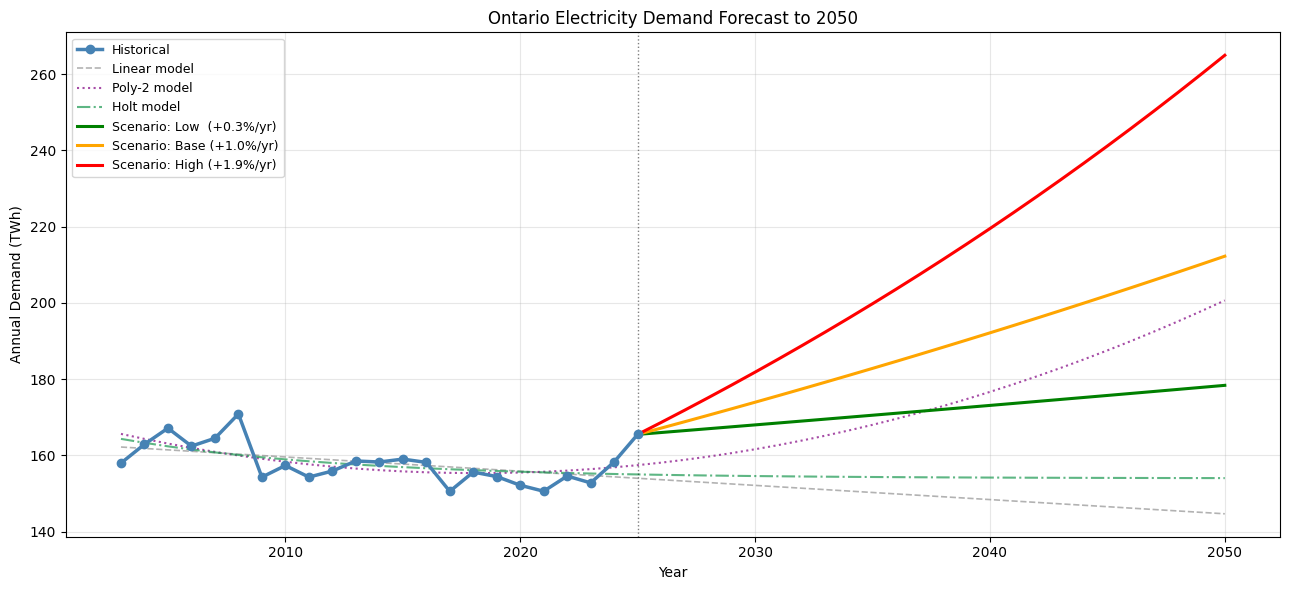

In [4]:
# Scenario forecasts anchored at 2025 actual value
# Growth rates reflect: low=efficiency gains, base=moderate electrification, high=aggressive EVs/heat-pumps/data-centres
base_2025 = df.loc[df['Year'] == 2025, 'TWh'].values[0]
future_years = np.arange(2025, 2051)

scenarios = {
    'Low  (+0.3%/yr)' : 0.003,
    'Base (+1.0%/yr)' : 0.010,
    'High (+1.9%/yr)' : 0.019,
}
colours = {'Low  (+0.3%/yr)': 'green', 'Base (+1.0%/yr)': 'orange', 'High (+1.9%/yr)': 'red'}

fig, ax = plt.subplots(figsize=(13, 6))

# Historical
ax.plot(df['Year'], df['TWh'], 'o-', color='steelblue', linewidth=2.5, label='Historical', zorder=5)

# Model forecasts (dashed, light)
ax.plot(all_years, lin_pred,   '--', color='gray',   alpha=0.6, linewidth=1.2, label='Linear model')
ax.plot(all_years, poly2_pred, ':',  color='purple',  alpha=0.7, linewidth=1.5, label='Poly-2 model')
ax.plot(all_years, holt_pred,  '-.', color='#1a9850', alpha=0.7, linewidth=1.5, label='Holt model')

# Scenario bands
for label, rate in scenarios.items():
    vals = base_2025 * (1 + rate) ** (future_years - 2025)
    ax.plot(future_years, vals, linewidth=2.2, color=colours[label], label=f'Scenario: {label}')

ax.axvline(2025, color='black', linestyle=':', alpha=0.5, linewidth=1)
ax.set(title='Ontario Electricity Demand Forecast to 2050',
       xlabel='Year', ylabel='Annual Demand (TWh)')
ax.legend(loc='upper left', fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


In [5]:
# Summary table: High scenario values for each year
rows = []
high_rate = scenarios['High (+1.9%/yr)']
for year in range(2025, 2051):
    row = {'Year': year, 'Demand (TWh)': round(base_2025 * (1 + high_rate) ** (year - 2025), 1)}
    rows.append(row)

summary_by_year = pd.DataFrame(rows)
print(f"\nHigh Scenario (+1.9%/yr) - Base year (2025): {base_2025:.1f} TWh\n")
print(summary_by_year.to_string(index=False))


High Scenario (+1.9%/yr) - Base year (2025): 165.5 TWh

 Year  Demand (TWh)
 2025         165.5
 2026         168.7
 2027         171.9
 2028         175.1
 2029         178.5
 2030         181.8
 2031         185.3
 2032         188.8
 2033         192.4
 2034         196.1
 2035         199.8
 2036         203.6
 2037         207.5
 2038         211.4
 2039         215.4
 2040         219.5
 2041         223.7
 2042         227.9
 2043         232.3
 2044         236.7
 2045         241.2
 2046         245.7
 2047         250.4
 2048         255.2
 2049         260.0
 2050         265.0


In [6]:
# Save the forecast table to file
summary_by_year.to_csv('./data/Ontario_Demand_Forecast.csv', index=False)
print("✓ Forecast table saved to ./data/Ontario_Demand_Forecast.csv")

✓ Forecast table saved to ./data/Ontario_Demand_Forecast.csv


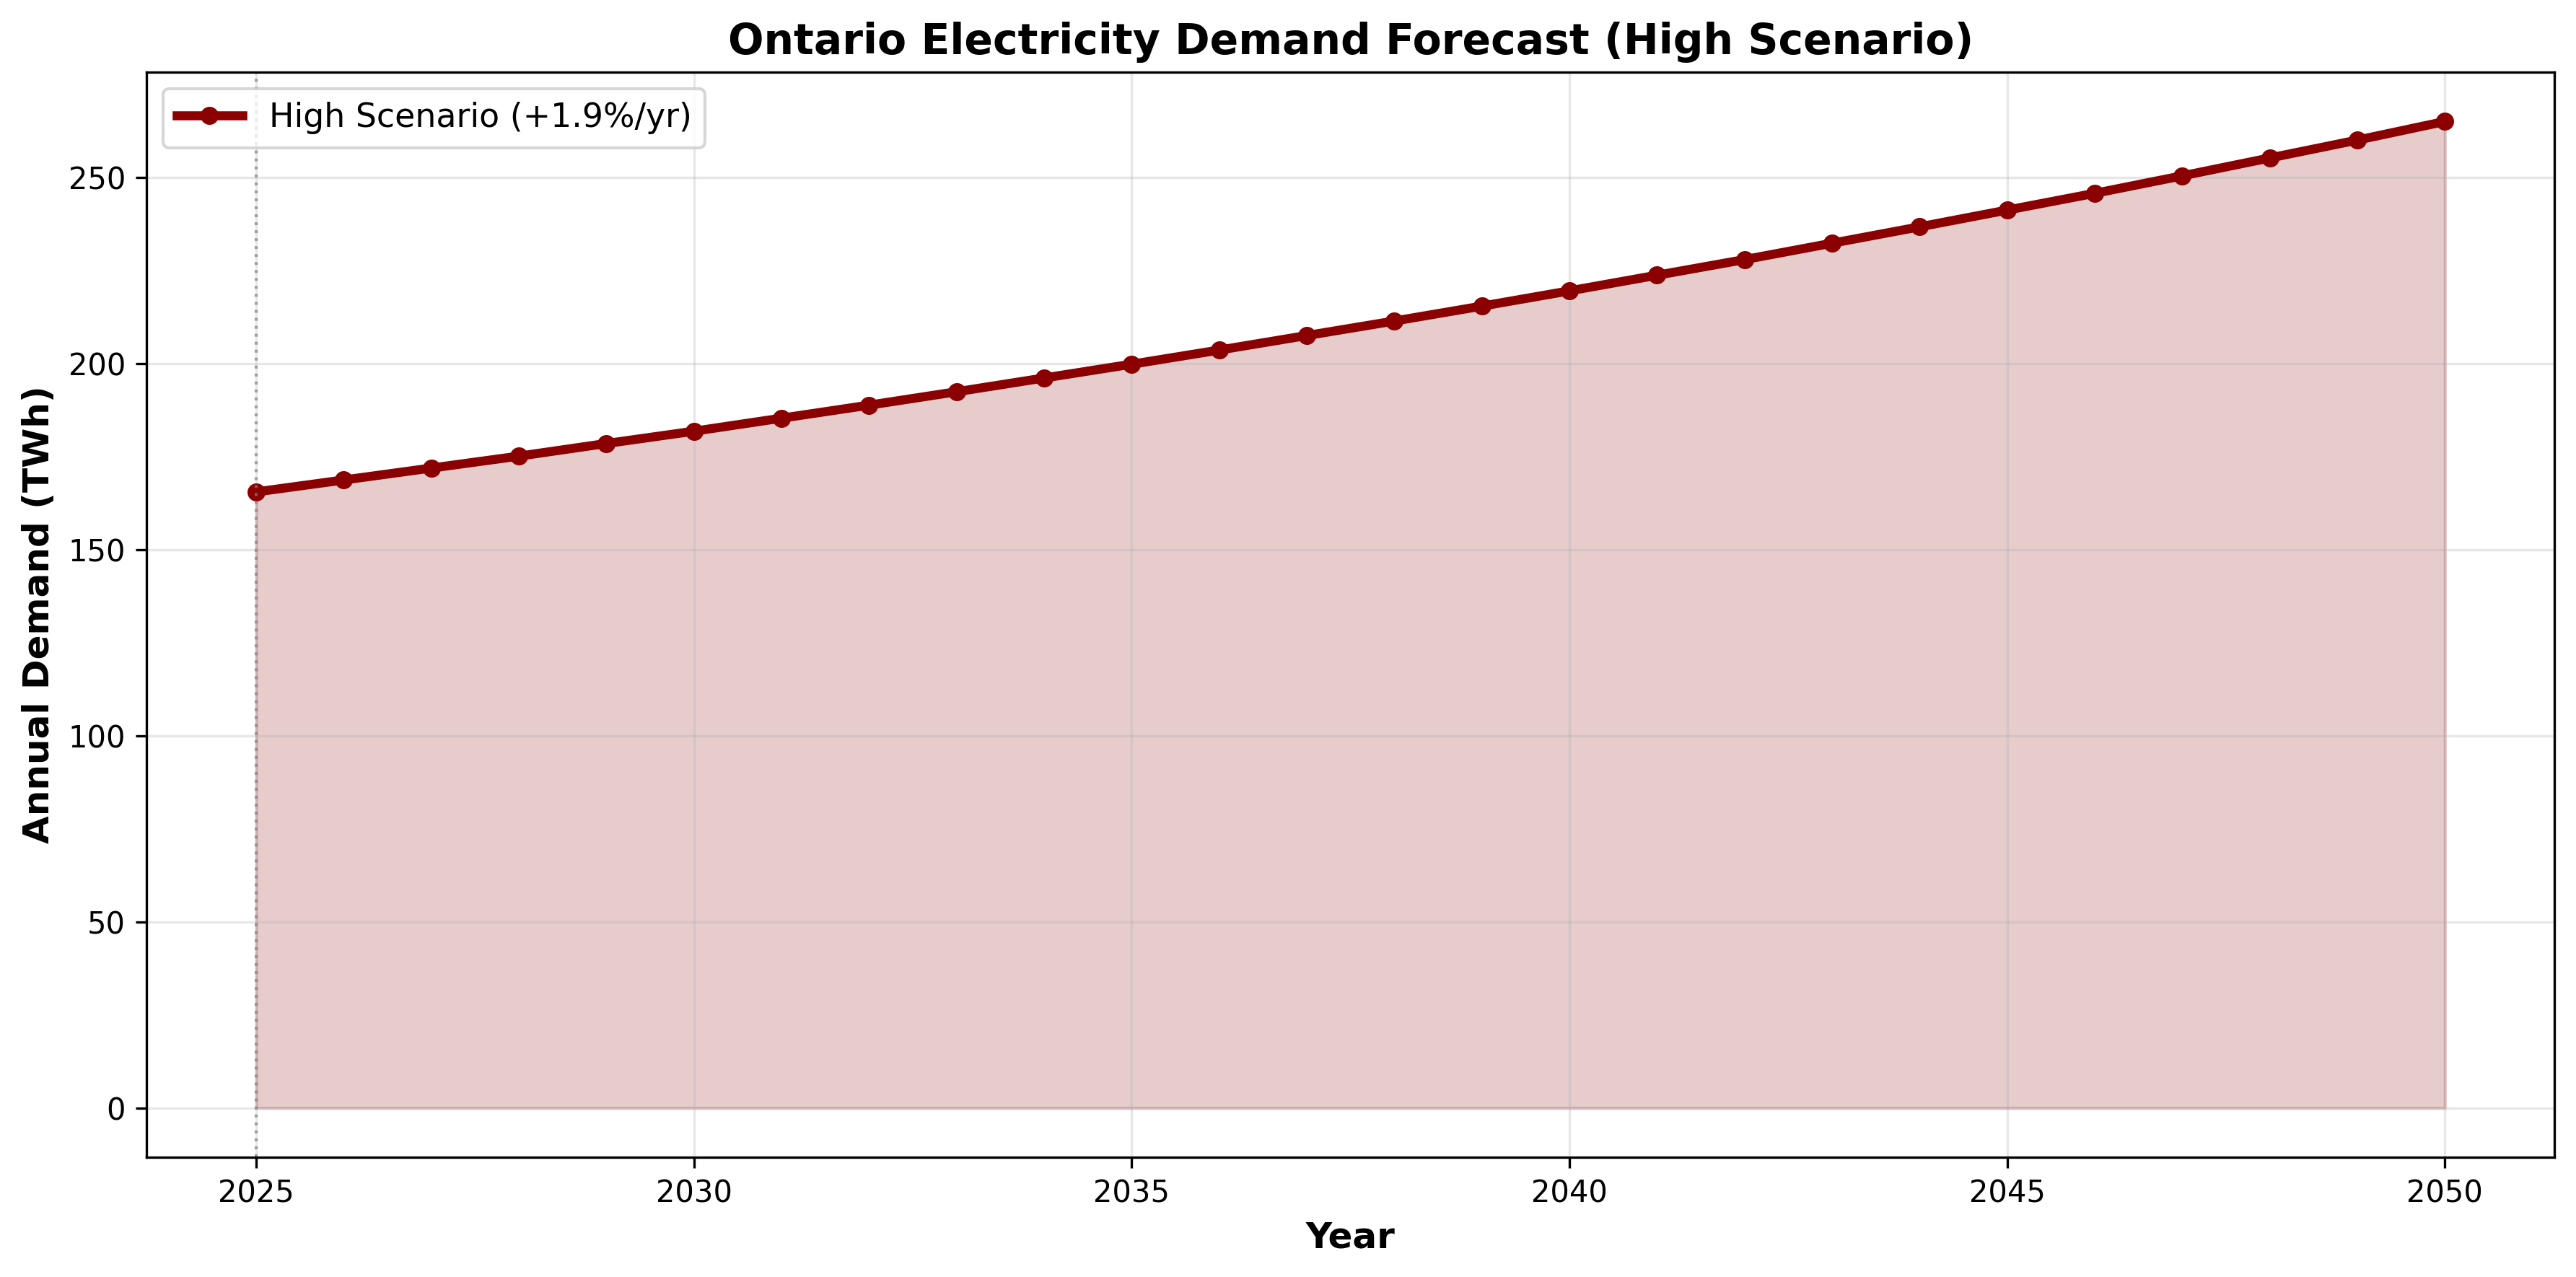

✓ Graph saved to ./data/Ontario_Demand_Forecast_High_Scenario.png


In [7]:
# Graph: High Scenario Demand Forecast
fig, ax = plt.subplots(figsize=(12, 6), dpi=300)

ax.plot(summary_by_year['Year'], summary_by_year['Demand (TWh)'], 
        linewidth=3, marker='o', markersize=5, color='darkred', label='High Scenario (+1.9%/yr)')

ax.fill_between(summary_by_year['Year'], summary_by_year['Demand (TWh)'], 
                alpha=0.2, color='darkred')

ax.axvline(2025, color='gray', linestyle=':', alpha=0.7, linewidth=1)
ax.set_xlabel('Year', fontsize=12, fontweight='bold')
ax.set_ylabel('Annual Demand (TWh)', fontsize=12, fontweight='bold')
ax.set_title('Ontario Electricity Demand Forecast (High Scenario)', fontsize=14, fontweight='bold')
ax.legend(fontsize=11, loc='upper left')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('./data/Ontario_Demand_Forecast_High_Scenario.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Graph saved to ./data/Ontario_Demand_Forecast_High_Scenario.png")

✓ Stacked generation chart saved to ./data/Generation_By_Source_Stacked.png

Generation by Source (TWh):
                          2005      2006      2007      2008      2009  \
_                                                                        
Hydro / Wave / Tidal  32.55529  32.55529  32.55529  32.55529  32.55529   
Wind                   3.07278   3.07278   3.07278   3.07278   3.07278   
Biomass / Geothermal   0.73510   0.73510   0.73510   0.73510   0.73510   
Solar                  0.11574   0.11574   0.11574   0.11574   0.11574   
Uranium               81.97500  81.97500  81.97500  81.97500  81.97500   
Coal & Coke           28.73408  23.80808  27.46872  22.63821  10.46115   
Natural Gas           16.88554  16.88554  16.88554  16.88554  16.88554   
Oil                    0.07347   0.07347   0.07347   0.07347   0.07347   

                          2010      2011      2012      2013      2014  ...  \
_                                                                       ...

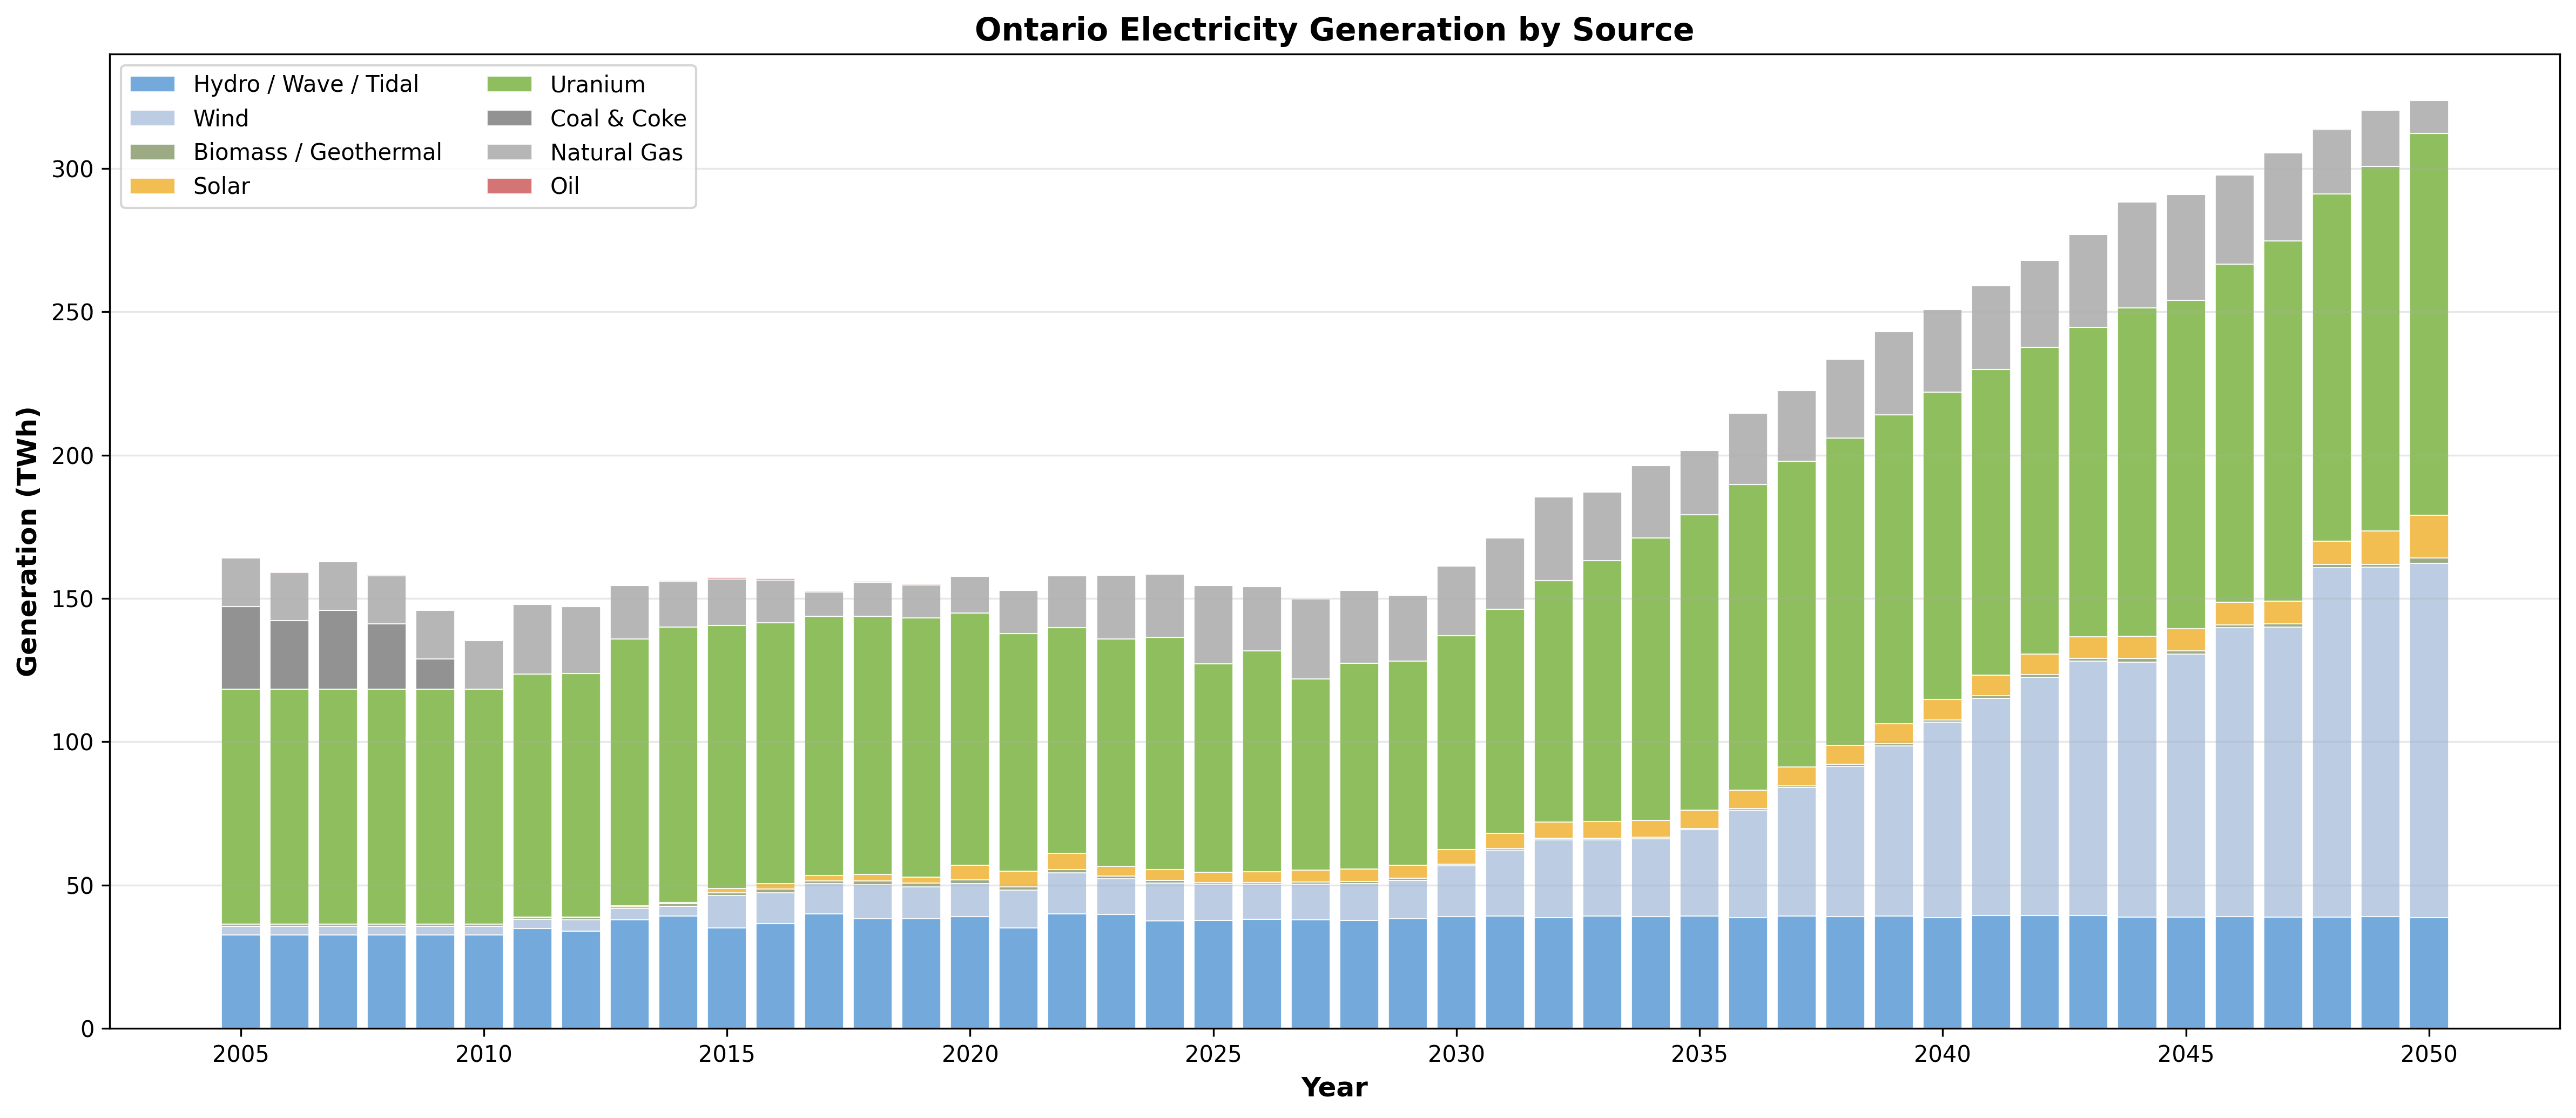

In [25]:
# Load Electricity Generation by Source
gen_source_df = pd.read_excel('./data/Electricity_Generation_By_Source_Ontario.xlsx')

# Set first column as source names (index)
gen_source_df = gen_source_df.set_index(gen_source_df.columns[0])

# Extract year columns (skip the index column)
year_columns = [col for col in gen_source_df.columns if isinstance(col, (int, float)) or str(col).isdigit()]
years = sorted([int(col) for col in year_columns])

# Get source names
sources = gen_source_df.index.tolist()

# Convert to TWh for consistency
gen_source_twh = gen_source_df[year_columns] / 1000

# Define colors for each source - natural, muted tones
colors_map = {
    'Hydro / Wave / Tidal': '#5B9BD5',
    'Wind': '#B0C4DE',
    'Biomass / Geothermal': '#8B9D6F',
    'Solar': '#F0B233',
    'Uranium': '#7CB342',
    'Natural Gas': '#A9A9A9',
    'Oil': '#CD5C5C',
    'Coal': '#000000',
    'Coke': '#5A6B75',
    'Other': '#808080'
}

# Use a colormap for sources not in the predefined list
colors_list = plt.cm.tab20(np.linspace(0, 1, len(sources)))
source_colors = [colors_map.get(source, colors_list[i]) for i, source in enumerate(sources)]

# Create stacked bar chart
fig, ax = plt.subplots(figsize=(16, 7), dpi=300)

bottom = np.zeros(len(years))
for idx, source in enumerate(sources):
    values = gen_source_twh.loc[source, year_columns].values
    ax.bar(years, values, bottom=bottom, label=source, color=source_colors[idx], alpha=0.85, edgecolor='white', linewidth=0.5)
    bottom += values

ax.set_xlabel('Year', fontsize=12, fontweight='bold')
ax.set_ylabel('Generation (TWh)', fontsize=12, fontweight='bold')
ax.set_title('Ontario Electricity Generation by Source', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
ax.legend(fontsize=10, loc='upper left', ncol=2)

# Set x-axis ticks to every 5 years
tick_years = list(range(min(years), max(years)+1, 5))
ax.set_xticks(tick_years)
ax.set_xticklabels(tick_years)

plt.tight_layout()
plt.savefig('./data/Generation_By_Source_Stacked.png', dpi=300, bbox_inches='tight')
print("✓ Stacked generation chart saved to ./data/Generation_By_Source_Stacked.png")
print("\nGeneration by Source (TWh):")
print(gen_source_twh)
plt.show()

In [10]:
# Combine historical demand (2005-2024) with forecasted demand (2025-2050)
historical_demand = df[(df['Year'] >= 2005) & (df['Year'] <= 2024)][['Year', 'TWh']].copy()
historical_demand.columns = ['Year', 'Demand (TWh)']

forecast_demand = summary_by_year[summary_by_year['Year'] >= 2025].copy()

combined_demand = pd.concat([historical_demand, forecast_demand], ignore_index=True)
print("Combined demand data (2005-2050):")
print(combined_demand)


Combined demand data (2005-2050):
    Year  Demand (TWh)
0   2005    167.153184
1   2006    162.442513
2   2007    164.491422
3   2008    170.876581
4   2009    154.300535
5   2010    157.360156
6   2011    154.319233
7   2012    155.905911
8   2013    158.542864
9   2014    158.273142
10  2015    159.031052
11  2016    158.174232
12  2017    150.578393
13  2018    155.631773
14  2019    154.455959
15  2020    152.173361
16  2021    150.607860
17  2022    154.593808
18  2023    152.796391
19  2024    158.303840
20  2025    165.500000
21  2026    168.700000
22  2027    171.900000
23  2028    175.100000
24  2029    178.500000
25  2030    181.800000
26  2031    185.300000
27  2032    188.800000
28  2033    192.400000
29  2034    196.100000
30  2035    199.800000
31  2036    203.600000
32  2037    207.500000
33  2038    211.400000
34  2039    215.400000
35  2040    219.500000
36  2041    223.700000
37  2042    227.900000
38  2043    232.300000
39  2044    236.700000
40  2045    241.200000


In [29]:
# Interactive Plotly Chart: Generation by Source + Demand Forecast
fig = go.Figure()

# Define colors for Plotly chart - natural, muted tones
colors_map_plotly = {
    'Hydro / Wave / Tidal': '#5B9BD5',
    'Wind': '#B0C4DE',
    'Biomass / Geothermal': '#8B9D6F',
    'Solar': '#F0B233',
    'Uranium': '#7CB342',
    'Natural Gas': '#A9A9A9',
    'Oil': '#CD5C5C',
    'Coal & Coke': '#000000',
    'Other': '#808080'
}

# Pre-assign consistent colors for all sources
source_colors_plotly = []
for source in sources:
    if source in colors_map_plotly:
        source_colors_plotly.append(colors_map_plotly[source])
    else:
        # Fallback: use a muted gray for unknown sources
        source_colors_plotly.append('#808080')

# Add stacked bars for each generation source
for idx, source in enumerate(sources):
    year_columns = [col for col in gen_source_df.columns if isinstance(col, (int, float)) or str(col).isdigit()]
    values = gen_source_twh.loc[source, year_columns].values
    fig.add_trace(go.Bar(
        x=years,
        y=values,
        name=source,
        marker_color=source_colors_plotly[idx],
        hovertemplate='<b>%{fullData.name}</b><br>Year: %{x}<br>Generation: %{y:.2f} TWh<extra></extra>'
    ))

# Add demand line overlay
fig.add_trace(go.Scatter(
    x=combined_demand['Year'],
    y=combined_demand['Demand (TWh)'],
    mode='lines+markers',
    name='Demand',
    line=dict(color='red', width=3),
    marker=dict(size=6),
    hovertemplate='<b>Demand</b><br>Year: %{x}<br>Demand: %{y:.2f} TWh<extra></extra>'
))

# Add shaded regions for historical and forecast
fig.add_vrect(x0=2005, x1=2025, fillcolor='lightblue', opacity=0.1, layer='below', line_width=0)
fig.add_vrect(x0=2025, x1=2050.5, fillcolor='lightcoral', opacity=0.1, layer='below', line_width=0)

# Add vertical line at 2025 boundary
fig.add_vline(x=2025, line_dash='dot', line_color='darkred', line_width=2, opacity=0.7)

# Add annotations closer to the boundary line
fig.add_annotation(
    x=2018, y=fig.data[-1]['y'].max() * 0.90,
    text='Historical Data',
    showarrow=False,
    font=dict(size=12, color='darkred'),
    bgcolor='white',
    bordercolor='darkred',
    borderwidth=1,
    borderpad=4
)

fig.add_annotation(
    x=2032, y=fig.data[-1]['y'].max() * 0.90,
    text='Forecast',
    showarrow=False,
    font=dict(size=12, color='darkred'),
    bgcolor='white',
    bordercolor='darkred',
    borderwidth=1,
    borderpad=4
)

# Update layout
fig.update_layout(
    title='Ontario Electricity Generation by Source + Demand Forecast',
    xaxis_title='Year',
    yaxis_title='Generation & Demand (TWh)',
    barmode='stack',
    hovermode='x unified',
    template='plotly_white',
    width=1200,
    height=600,
    font=dict(size=11),
    legend=dict(
        yanchor='top',
        y=0.99,
        xanchor='left',
        x=0.01,
        bgcolor='rgba(255, 255, 255, 0.8)',
        bordercolor='gray',
        borderwidth=1
    ),
    xaxis=dict(
        tickmode='linear',
        tick0=2005,
        dtick=5,
        gridwidth=1,
        gridcolor='lightgray'
    ),
    yaxis=dict(
        gridwidth=1,
        gridcolor='lightgray'
    )
)

fig.show()
print("✓ Interactive Plotly chart generated successfully")

fig.write_html('./data/Generation_By_Source_With_Demand_Interactive.html')
print("✓ Chart saved to ./data/Generation_By_Source_With_Demand_Interactive.html")

✓ Interactive Plotly chart generated successfully
✓ Chart saved to ./data/Generation_By_Source_With_Demand_Interactive.html
